# EDA hành vi & performance theo category — **1010** và **1020** (đào sâu, không so sánh)

Mỗi mã được phân tích **riêng**: cùng bộ câu hỏi, chart chỉ một category, export vào `outputs/eda_category_behavior/{category}/`.

## Quy tắc `is_login` (bắt buộc)

| Bảng | Cách lọc user quan sát / tương tác |
|------|-------------------------------------|
| `fact_user_events` | Chỉ `is_login = 'login'` |
| `fact_post_contact_interactions` | Không có cột `is_login` → chỉ giữ `user_id` thuộc tập **login users** (có ≥1 event login trong category đó) |
| `dim_listing`, `fact_listing_snapshot` | Supply / exposure — **không** lọc login |

Non-login: `user_id` đổi theo session (README) → **không** dùng cho cohort user marketing.

## 4 lớp phân tích (mỗi category)

1. **Supply** (`dim_listing`) — cấu trúc tin, địa lý, giá, field đặc thù  
2. **Exposure** (`fact_listing_snapshot`) — views, contacts, tuổi tin, view→contact  
3. **Hành vi clickstream** (events, login) — device, surface, funnel session, dwell, giờ  
4. **Hành vi sau contact** (interactions, login users) — lead, chat, phân khúc intent  

Cuối mỗi category: **marketing scorecard** (điểm mạnh / yếu có số).

**Chạy:** Run All từ Setup. RAM thấp: tăng `EVENT_SAMPLE_FRAC` / `FUNNEL_SAMPLE_FRAC`.  


## Phân tầng `event_type` (không gom `other_interaction` với contact thật)

| Tầng | `event_type` / điều kiện | Ý nghĩa business |
|------|-------------------------|------------------|
| **Explicit contact** | `view_phone`, `contact_chat`, `contact_zalo`, `contact_sms` | Lead / doanh thu |
| **Other interaction** | `other_interaction` | Chủ yếu `surface=ad_view` (~94–96%) — exposure trên ad, **không** thay contact thật |
| **Browse** | `pageview` | Xem tin |

Funnel & scorecard dùng **explicit contact**; `other_interaction` có bảng **cấu thành `surface`** riêng.

**Export:** `outputs/eda_category_behavior/`

In [4]:
%matplotlib inline
from __future__ import annotations

import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

DATA_ROOT = Path.cwd().resolve()
for name in (
    "dim_listing",
    "fact_user_events",
    "fact_listing_snapshot",
    "fact_post_contact_interactions",
):
    if not (DATA_ROOT / name).exists():
        raise FileNotFoundError(f"Thiếu `{name}` trong {DATA_ROOT}")

OUT_ROOT = DATA_ROOT / "outputs" / "eda_category_behavior"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

DIM_GLOB = str(DATA_ROOT / "dim_listing" / "*.parquet")
EVENTS_GLOB = str(DATA_ROOT / "fact_user_events" / "*.parquet")
SNAP_GLOB = str(DATA_ROOT / "fact_listing_snapshot" / "*.parquet")
INTER_GLOB = str(DATA_ROOT / "fact_post_contact_interactions" / "*.parquet")

DUCKDB_MEMORY_LIMIT = "2GB"
DUCKDB_THREADS = 2
# None = full; 0.05–0.12 nếu thiếu RAM
EVENT_SAMPLE_FRAC: float | None = 0.08
FUNNEL_SAMPLE_FRAC: float | None = 0.08

LOGIN_WHERE = "is_login = 'login'"
EXPLICIT_TYPES = (
    "view_phone", "contact_chat", "contact_zalo", "contact_sms",
)
EXPLICIT_CONTACT_SQL = ", ".join(repr(x) for x in EXPLICIT_TYPES)
POSITIVE_TYPES = EXPLICIT_TYPES + ("other_interaction",)
POS_SQL = ", ".join(repr(x) for x in POSITIVE_TYPES)

CAT_META = {
    1010: "1010 — Căn hộ / Chung cư",
    1020: "1020 — Nhà ở",
}
CATEGORIES = (1010, 1020)

con = duckdb.connect(":memory:")
con.execute(f"PRAGMA memory_limit='{DUCKDB_MEMORY_LIMIT}'")
con.execute(f"PRAGMA threads={DUCKDB_THREADS}")


def sample_clause(frac: float | None) -> str:
    if frac is None:
        return ""
    return f"AND random() < {float(frac)}"


def cat_out(cat: int) -> Path:
    p = OUT_ROOT / str(cat)
    p.mkdir(parents=True, exist_ok=True)
    return p


def show_df(df: pd.DataFrame, title: str):
    display(Markdown(f"**{title}**"))
    display(df)


def save_fig(path: Path, dpi: int = 120):
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.show()
    print("Saved", path)


def pct_col(s: pd.Series) -> pd.Series:
    t = float(s.sum())
    return (100.0 * s / t).round(2) if t else s.astype(float)


print("OUT_ROOT =", OUT_ROOT)
print("EVENT_SAMPLE_FRAC =", EVENT_SAMPLE_FRAC)
print("FUNNEL_SAMPLE_FRAC =", FUNNEL_SAMPLE_FRAC)
print("Login filter (events):", LOGIN_WHERE)

# Login users per category (cho interactions)
for cat in CATEGORIES:
    con.execute(f"""
    CREATE OR REPLACE TEMP TABLE login_users_{cat} AS
    SELECT DISTINCT user_id
    FROM read_parquet('{EVENTS_GLOB}')
    WHERE category = {cat} AND {LOGIN_WHERE}
    """)
    n = con.execute(f"SELECT COUNT(*) FROM login_users_{cat}").fetchone()[0]
    print(f"login_users_{cat}: {n:,}")


OUT_ROOT = /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_category_behavior
EVENT_SAMPLE_FRAC = 0.08
FUNNEL_SAMPLE_FRAC = 0.08
Login filter (events): is_login = 'login'


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

login_users_1010: 379,137


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

login_users_1020: 606,817


## Engine — chạy deep-dive cho **một** category

Hàm `deepdive_category(cat)` lặp 4 lớp + scorecard. Không vẽ 1010 vs 1020 trên cùng chart.

In [5]:
def deepdive_category(cat: int) -> None:
    label = CAT_META[cat]
    out = cat_out(cat)
    display(Markdown(f"# {label}"))
    print("Export →", out)

    # ── 1. Supply (dim_listing) ─────────────────────────────────────────
    supply = con.execute(f"""
    SELECT
        ad_type,
        COUNT(*)::BIGINT AS listings,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM read_parquet('{DIM_GLOB}')
    WHERE category = {cat}
    GROUP BY 1 ORDER BY listings DESC
    """).df()
    show_df(supply, f"{label} — Mix ad_type (supply)")
    supply.to_csv(out / "01_supply_ad_type.csv", index=False)

  # Top cities
    geo = con.execute(f"""
    SELECT city_name, COUNT(*)::BIGINT AS listings,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM read_parquet('{DIM_GLOB}')
    WHERE category = {cat} AND city_name IS NOT NULL
    GROUP BY 1 ORDER BY listings DESC LIMIT 15
    """).df()
    show_df(geo, f"{label} — Top 15 city (supply)")
    geo.to_csv(out / "01_supply_top_cities.csv", index=False)

    if cat == 1010:
        struct_sql = """
        SELECT
            CASE WHEN project_id IS NOT NULL AND TRIM(CAST(project_id AS VARCHAR)) != ''
                 THEN 'has_project' ELSE 'no_project' END AS project_flag,
            CASE WHEN bedrooms IS NULL OR bedrooms <= 0 THEN 'unk' WHEN bedrooms >= 4 THEN '4+'
                 ELSE CAST(CAST(bedrooms AS INT) AS VARCHAR) END AS bed_bucket,
            COUNT(*)::BIGINT AS listings
        FROM read_parquet('{dim}')
        WHERE category = {cat}
        GROUP BY 1, 2 ORDER BY listings DESC
        """
    else:
        struct_sql = """
        SELECT
            COALESCE(NULLIF(TRIM(CAST(house_type AS VARCHAR)), ''), '(blank)') AS house_type,
            CASE WHEN floors IS NULL OR floors <= 0 THEN 'unk'
                 WHEN floors <= 2 THEN '1-2' WHEN floors <= 4 THEN '3-4' ELSE '5+' END AS floors_bucket,
            COUNT(*)::BIGINT AS listings
        FROM read_parquet('{dim}')
        WHERE category = {cat}
        GROUP BY 1, 2 ORDER BY listings DESC LIMIT 40
        """
    struct = con.execute(
        struct_sql.format(dim=DIM_GLOB, cat=cat)
    ).df()
    show_df(struct.head(25), f"{label} — Cột đặc thù supply")
    struct.to_csv(out / "01_supply_structural.csv", index=False)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(supply["ad_type"].astype(str), supply["pct"], color="#238b45" if cat == 1010 else "#2171b5")
    ax.set_ylabel("% listings")
    ax.set_title(f"{label} — Supply mix ad_type")
    save_fig(out / "fig_01_supply_ad_type.png")

    # ── 2. Exposure (snapshot × dim) ───────────────────────────────────
    snap = con.execute(f"""
    WITH d AS (
        SELECT CAST(item_id AS VARCHAR) AS item_id, ad_type
        FROM read_parquet('{DIM_GLOB}') WHERE category = {cat}
    ),
    s AS (
        SELECT CAST(item_id AS VARCHAR) AS item_id,
               views_24h, contacts_24h, listing_age_days
        FROM read_parquet('{SNAP_GLOB}')
    )
    SELECT
        d.ad_type,
        COUNT(*)::BIGINT AS listing_days,
        ROUND(AVG(s.views_24h), 2) AS avg_views_24h,
        ROUND(AVG(s.contacts_24h), 3) AS avg_contacts_24h,
        ROUND(AVG(s.listing_age_days), 1) AS avg_age_days,
        ROUND(100.0 * SUM(CASE WHEN s.contacts_24h > 0 THEN 1 ELSE 0 END)
              / NULLIF(COUNT(*), 0), 2) AS pct_days_with_contact
    FROM s
    INNER JOIN d ON s.item_id = d.item_id
    GROUP BY 1 ORDER BY 1
    """).df()
    show_df(snap, f"{label} — Snapshot theo ad_type")
    snap.to_csv(out / "02_snapshot_by_adtype.csv", index=False)

    # ── 3. Events — login only (tách explicit contact vs other_interaction) ─
    ev_layers = con.execute(f"""
    SELECT
        CASE
            WHEN event_type = 'pageview' THEN 'pageview'
            WHEN event_type = 'other_interaction' THEN 'other_interaction'
            WHEN event_type IN ({EXPLICIT_CONTACT_SQL}) THEN 'explicit_contact'
            ELSE 'other_event_type'
        END AS event_layer,
        COUNT(*)::BIGINT AS events,
        COUNT(DISTINCT user_id)::BIGINT AS users,
        COUNT(DISTINCT session_id)::BIGINT AS sessions
    FROM read_parquet('{EVENTS_GLOB}')
    WHERE category = {cat} AND {LOGIN_WHERE} {sample_clause(EVENT_SAMPLE_FRAC)}
    GROUP BY 1 ORDER BY events DESC
    """).df()
    ev_layers["pct_events"] = pct_col(ev_layers["events"])
    show_df(ev_layers, f"{label} — Phân tầng event (login, không gom other=contact)")
    ev_layers.to_csv(out / "03_events_login_event_layers.csv", index=False)

    ev_explicit = con.execute(f"""
    SELECT event_type, COUNT(*)::BIGINT AS events, COUNT(DISTINCT user_id)::BIGINT AS users
    FROM read_parquet('{EVENTS_GLOB}')
    WHERE category = {cat} AND {LOGIN_WHERE}
      AND event_type IN ({EXPLICIT_CONTACT_SQL})
      {sample_clause(EVENT_SAMPLE_FRAC)}
    GROUP BY 1 ORDER BY events DESC
    """).df()
    ev_explicit["pct_of_explicit"] = pct_col(ev_explicit["events"])
    show_df(ev_explicit, f"{label} — Explicit contact breakdown (login)")
    ev_explicit.to_csv(out / "03_events_login_explicit_contact_mix.csv", index=False)

    oi_comp = con.execute(f"""
    SELECT
        COALESCE(NULLIF(TRIM(CAST(surface AS VARCHAR)), ''), '(blank)') AS surface,
        device,
        COUNT(*)::BIGINT AS events,
        COUNT(DISTINCT user_id)::BIGINT AS users,
        COUNT(DISTINCT session_id)::BIGINT AS sessions
    FROM read_parquet('{EVENTS_GLOB}')
    WHERE category = {cat} AND {LOGIN_WHERE}
      AND event_type = 'other_interaction'
      {sample_clause(EVENT_SAMPLE_FRAC)}
    GROUP BY 1, 2
    ORDER BY events DESC
    LIMIT 30
    """).df()
    oi_comp["pct_of_other_interaction"] = (
        100.0 * oi_comp["events"] / oi_comp["events"].sum()
    ).round(2)
    show_df(oi_comp.head(20), f"{label} — Cấu thành other_interaction (surface × device)")
    oi_comp.to_csv(out / "03_events_login_other_interaction_composition.csv", index=False)

    oi_surface = con.execute(f"""
    SELECT
        COALESCE(NULLIF(TRIM(CAST(surface AS VARCHAR)), ''), '(blank)') AS surface,
        COUNT(*)::BIGINT AS events
    FROM read_parquet('{EVENTS_GLOB}')
    WHERE category = {cat} AND {LOGIN_WHERE}
      AND event_type = 'other_interaction'
      {sample_clause(EVENT_SAMPLE_FRAC)}
    GROUP BY 1 ORDER BY events DESC
    """).df()
    oi_surface["pct_of_other_interaction"] = pct_col(oi_surface["events"])
    show_df(oi_surface, f"{label} — other_interaction theo surface")
    oi_surface.to_csv(out / "03_events_login_other_interaction_surface.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].bar(
        ev_layers["event_layer"].astype(str),
        ev_layers["pct_events"],
        color=["#bdbdbd", "#fed976", "#238b45"][: len(ev_layers)],
    )
    axes[0].set_ylabel("% events")
    axes[0].set_title("Phân tầng event")
    axes[0].tick_params(axis="x", rotation=25)
    axes[1].bar(
        oi_surface["surface"].astype(str).head(8),
        oi_surface["pct_of_other_interaction"].head(8),
        color="#fd8d3c",
    )
    axes[1].set_ylabel("% trong other_interaction")
    axes[1].set_title("other_interaction → surface (top)")
    axes[1].tick_params(axis="x", rotation=30)
    plt.suptitle(f"{label} — Event taxonomy (login sample)")
    save_fig(out / "fig_03_event_layers_and_other_surface.png")

    device = con.execute(f"""
    SELECT device, COUNT(*)::BIGINT AS events,
           COUNT(DISTINCT user_id)::BIGINT AS users,
           COUNT(DISTINCT session_id)::BIGINT AS sessions
    FROM read_parquet('{EVENTS_GLOB}')
    WHERE category = {cat} AND {LOGIN_WHERE} {sample_clause(EVENT_SAMPLE_FRAC)}
    GROUP BY 1 ORDER BY events DESC
    """).df()
    device["pct_events"] = pct_col(device["events"])
    show_df(device, f"{label} — Device (login, all events)")
    device.to_csv(out / "03_events_login_device.csv", index=False)

    # Session funnel: contact = explicit contact ONLY
    funnel = con.execute(f"""
    WITH ev AS (
        SELECT session_id, event_type, dwell_time_sec, query
        FROM read_parquet('{EVENTS_GLOB}')
        WHERE category = {cat} AND {LOGIN_WHERE} {sample_clause(FUNNEL_SAMPLE_FRAC)}
    ),
    sess AS (
        SELECT
            session_id,
            MAX(CASE WHEN query IS NOT NULL AND TRIM(CAST(query AS VARCHAR)) != '' THEN 1 ELSE 0 END) AS has_search,
            MAX(CASE WHEN event_type = 'pageview' THEN 1 ELSE 0 END) AS has_view,
            MAX(CASE WHEN event_type = 'pageview' AND dwell_time_sec > 30 THEN 1 ELSE 0 END) AS has_consider,
            MAX(CASE WHEN event_type IN ({EXPLICIT_CONTACT_SQL}) THEN 1 ELSE 0 END) AS has_explicit_contact,
            MAX(CASE WHEN event_type = 'other_interaction' THEN 1 ELSE 0 END) AS has_other_interaction
        FROM ev
        GROUP BY 1
    )
    SELECT
        COUNT(*)::BIGINT AS sessions,
        SUM(has_search)::BIGINT AS search_sessions,
        SUM(has_view)::BIGINT AS view_sessions,
        SUM(has_consider)::BIGINT AS consider_sessions,
        SUM(has_explicit_contact)::BIGINT AS explicit_contact_sessions,
        SUM(has_other_interaction)::BIGINT AS other_interaction_sessions
    FROM sess
    """).df()
    funnel_pct = pd.DataFrame()
    if len(funnel) and funnel["sessions"].iloc[0] > 0:
        s = funnel.iloc[0]
        funnel_pct = pd.DataFrame({
            "stage": [
                "search",
                "view",
                "consider",
                "explicit_contact",
                "other_interaction",
            ],
            "pct_of_sessions": [
                100 * s["search_sessions"] / s["sessions"],
                100 * s["view_sessions"] / s["sessions"],
                100 * s["consider_sessions"] / s["sessions"],
                100 * s["explicit_contact_sessions"] / s["sessions"],
                100 * s["other_interaction_sessions"] / s["sessions"],
            ],
        }).round(2)
        show_df(funnel_pct, f"{label} — Session funnel % (login; contact = explicit only)")
        funnel_pct.to_csv(out / "03_events_login_funnel.csv", index=False)

    hour = con.execute(f"""
    SELECT EXTRACT('hour' FROM event_ts)::INT AS hour, COUNT(*)::BIGINT AS events
    FROM read_parquet('{EVENTS_GLOB}')
    WHERE category = {cat} AND {LOGIN_WHERE} {sample_clause(EVENT_SAMPLE_FRAC)}
    GROUP BY 1 ORDER BY 1
    """).df()
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(hour["hour"], hour["events"], marker="o")
    ax.set_xlabel("Hour"); ax.set_ylabel("Events (login sample)")
    ax.set_title(f"{label} — Activity by hour")
    save_fig(out / "fig_03_events_hour.png")

    # ── 4. Interactions — login users only ─────────────────────────────
    inter = con.execute(f"""
    SELECT
        SUM(i.adview_count)::BIGINT AS adviews,
        SUM(i.lead_count)::BIGINT AS leads,
        SUM(i.chat_message_count)::BIGINT AS messages,
        ROUND(AVG(i.chat_turn_count), 2) AS avg_chat_turns,
        COUNT(DISTINCT i.user_id)::BIGINT AS users,
        COUNT(DISTINCT i.item_id)::BIGINT AS items
    FROM read_parquet('{INTER_GLOB}') AS i
    INNER JOIN login_users_{cat} AS u ON i.user_id = u.user_id
    WHERE i.category = {cat}
    """).df()
    show_df(inter, f"{label} — Interactions aggregate (login users)")
    inter.to_csv(out / "04_interactions_login_summary.csv", index=False)

    prof = con.execute(f"""
    SELECT
        i.user_id,
        SUM(i.adview_count) AS total_views,
        SUM(i.lead_count) AS total_leads,
        SUM(i.chat_message_count) AS total_messages,
        AVG(i.chat_turn_count) AS avg_turns,
        COUNT(DISTINCT i.item_id) AS distinct_items
    FROM read_parquet('{INTER_GLOB}') AS i
    INNER JOIN login_users_{cat} AS u ON i.user_id = u.user_id
    WHERE i.category = {cat}
    GROUP BY 1
    HAVING SUM(i.adview_count) > 0
    """).df()

    def segment(row):
        v, l, m, t, n = row.total_views, row.total_leads, row.total_messages, row.avg_turns or 0, row.distinct_items
        if n >= 15 and m > 0 and t <= 1.5:
            return "C_spam_broker"
        if v > 50 and l == 0 and m == 0:
            return "B_window_shopper"
        if v <= 10 and (l >= 2 or t > 5):
            return "A_high_intent"
        return "D_other"

    if len(prof):
        prof["segment"] = prof.apply(segment, axis=1)
        seg = prof.groupby("segment").size().reset_index(name="users")
        seg["pct"] = pct_col(seg["users"])
        show_df(seg.sort_values("users", ascending=False), f"{label} — Lead segments (login users)")
        seg.to_csv(out / "04_interactions_login_segments.csv", index=False)
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(seg["segment"], seg["pct"], color="#6a51a3", edgecolor="black", linewidth=0.3)
        ax.set_ylabel("% users"); ax.set_title(f"{label} — Intent segments")
        plt.xticks(rotation=20, ha="right")
        save_fig(out / "fig_04_lead_segments.png")

    # ── 5. Marketing scorecard (heuristic từ số vừa tính) ─────────────
    rows = []
    let_pct = float(supply.loc[supply.ad_type == "let", "pct"].sum()) if "let" in supply.ad_type.values else 0
    sell_pct = float(supply.loc[supply.ad_type == "sell", "pct"].sum()) if "sell" in supply.ad_type.values else 0
    rows.append(("supply", "let_share_pct", let_pct, "mạnh" if let_pct > 50 else "yếu", "Tỷ trọng cho thuê trong catalog"))
    rows.append(("supply", "sell_share_pct", sell_pct, "mạnh" if sell_pct > 50 else "yếu", "Tỷ trọng bán trong catalog"))

    if len(ev_layers):
        explicit_pct = float(
            ev_layers.loc[ev_layers.event_layer == "explicit_contact", "pct_events"].sum()
        )
        other_pct = float(
            ev_layers.loc[ev_layers.event_layer == "other_interaction", "pct_events"].sum()
        )
        rows.append((
            "behavior_login", "explicit_contact_event_pct", explicit_pct,
            "mạnh" if explicit_pct > 5 else "cần cải thiện",
            "Contact thật (view_phone/chat/zalo/sms) — gắn doanh thu",
        ))
        rows.append((
            "behavior_login", "other_interaction_event_pct", other_pct,
            "theo dõi riêng",
            "Chủ yếu ad_view surface — KHÔNG gom vào contact thật",
        ))
        if len(oi_surface) and oi_surface["surface"].iloc[0]:
            top_surf = str(oi_surface["surface"].iloc[0])
            top_pct = float(oi_surface["pct_of_other_interaction"].iloc[0])
            rows.append((
                "behavior_login", "other_interaction_top_surface_pct", top_pct,
                "cấu trúc",
                f"other_interaction top surface={top_surf}",
            ))

    if len(funnel_pct):
        explicit_sess = float(
            funnel_pct.loc[funnel_pct.stage == "explicit_contact", "pct_of_sessions"].iloc[0]
        )
        rows.append((
            "behavior_login", "session_explicit_contact_pct", explicit_sess,
            "mạnh" if explicit_sess > 8 else "cần cải thiện",
            "% session login có ≥1 explicit contact",
        ))

    if len(prof):
        hi = float(seg.loc[seg.segment == "A_high_intent", "pct"].sum()) if "A_high_intent" in seg.segment.values else 0
        win = float(seg.loc[seg.segment == "B_window_shopper", "pct"].sum()) if "B_window_shopper" in seg.segment.values else 0
        rows.append(("interactions_login", "high_intent_user_pct", hi, "mạnh" if hi > 10 else "yếu", "User login high-intent"))
        rows.append(("interactions_login", "window_shopper_pct", win, "rủi ro" if win > 25 else "ổn", "User xem nhiều, không lead"))

    score = pd.DataFrame(rows, columns=["layer", "metric", "value", "signal", "marketing_note"])
    show_df(score, f"{label} — Marketing scorecard (draft)")
    score.to_csv(out / "05_marketing_scorecard.csv", index=False)
    print("Done", label)


## Chạy deep-dive — lần lượt từng category

# 1010 — Căn hộ / Chung cư

Export → /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_category_behavior/1010


**1010 — Căn hộ / Chung cư — Mix ad_type (supply)**

,ad_type,listings,pct
0,let,454716,74.32
1,sell,157107,25.68


**1010 — Căn hộ / Chung cư — Top 15 city (supply)**

,city_name,listings,pct
0,Tp Hồ Chí Minh,453165,74.07
1,Hà Nội,63619,10.40
2,Đà Nẵng,38107,6.23
3,Bình Dương,35452,5.79
4,Khánh Hòa,3784,0.62
5,Đồng Nai,3723,0.61
6,Cần Thơ,3705,0.61
7,Bà Rịa - Vũng Tàu,2961,0.48
8,Long An,1955,0.32
9,Hải Phòng,926,0.15


**1010 — Căn hộ / Chung cư — Cột đặc thù supply**

,project_flag,bed_bucket,listings
0,no_project,1,262289
1,has_project,2,151663
2,no_project,2,75988
3,has_project,1,52456
4,has_project,3,45755
5,no_project,3,14901
6,no_project,4+,5332
7,has_project,4+,3411
8,no_project,unk,28


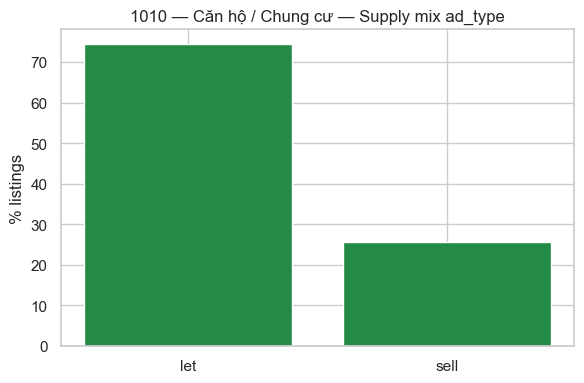

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_category_behavior/1010/fig_01_supply_ad_type.png


**1010 — Căn hộ / Chung cư — Snapshot theo ad_type**

,ad_type,listing_days,avg_views_24h,avg_contacts_24h,avg_age_days,pct_days_with_contact
0,let,2422216,5.52,2.294,52.3,11.07
1,sell,1146286,4.52,2.189,52.4,10.97


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**1010 — Căn hộ / Chung cư — Phân tầng event (login, không gom other=contact)**

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**1010 — Căn hộ / Chung cư — Cấu thành other_interaction (surface × device)**

,surface,device,events,users,sessions,pct_of_other_interaction
0,ad_view,Desktop,302783,35445,91337,46.44
1,ad_view,iOS,128544,43038,81216,19.71
2,ad_view,MSite,94886,19682,40134,14.55
3,ad_view,Android,85577,25657,48055,13.12
4,adview,Desktop,26642,10808,14728,4.09
5,adview,MSite,13485,7380,9089,2.07
6,adview,Android,121,115,116,0.02


**1010 — Căn hộ / Chung cư — other_interaction theo surface**

,surface,events,pct_of_other_interaction
0,ad_view,611697,93.81
1,adview,40391,6.19


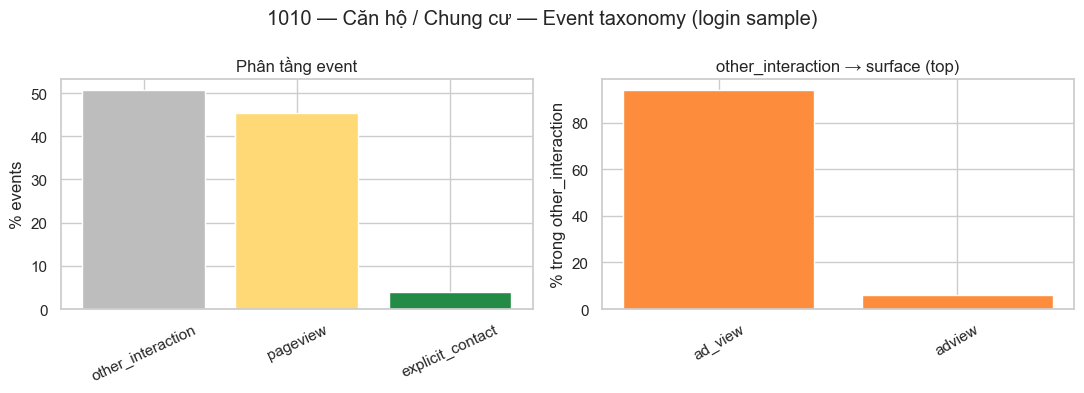

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_category_behavior/1010/fig_03_event_layers_and_other_surface.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**1010 — Căn hộ / Chung cư — Device (login, all events)**

,device,events,users,sessions,pct_events
0,iOS,511400,98528,259498,39.62
1,Desktop,423565,41297,121509,32.81
2,Android,197666,45140,105123,15.31
3,MSite,158189,26109,59859,12.25


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**1010 — Căn hộ / Chung cư — Session funnel % (login; contact = explicit only)**

,stage,pct_of_sessions
0,search,6.68
1,view,69.49
2,consider,64.39
3,explicit_contact,7.78
4,other_interaction,49.96


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

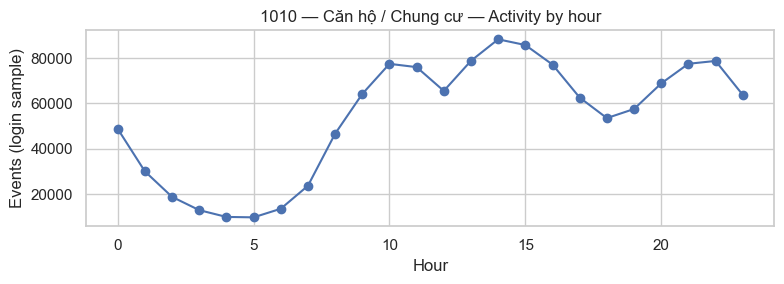

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_category_behavior/1010/fig_03_events_hour.png


**1010 — Căn hộ / Chung cư — Interactions aggregate (login users)**

,adviews,leads,messages,avg_chat_turns,users,items
0,4032556,510639,1025441,0.64,242214,106050


**1010 — Căn hộ / Chung cư — Lead segments (login users)**

,segment,users,pct
2,D_other,199139,82.74
1,C_spam_broker,23054,9.58
0,A_high_intent,18494,7.68


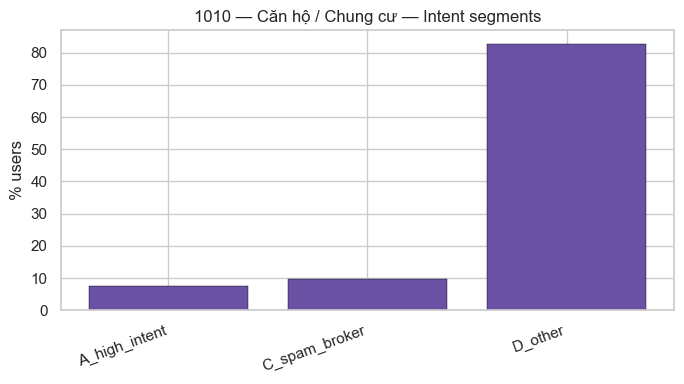

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_category_behavior/1010/fig_04_lead_segments.png


**1010 — Căn hộ / Chung cư — Marketing scorecard (draft)**

,layer,metric,value,signal,marketing_note
0,supply,let_share_pct,74.32,mạnh,Tỷ trọng cho thuê trong catalog
1,supply,sell_share_pct,25.68,yếu,Tỷ trọng bán trong catalog
2,behavior_login,explicit_contact_event_pct,3.97,cần cải thiện,Contact thật (view_phone/chat/zalo/sms) — gắn ...
3,behavior_login,other_interaction_event_pct,50.61,theo dõi riêng,Chủ yếu ad_view surface — KHÔNG gom vào contac...
4,behavior_login,other_interaction_top_surface_pct,93.81,cấu trúc,other_interaction top surface=ad_view
5,behavior_login,session_explicit_contact_pct,7.78,cần cải thiện,% session login có ≥1 explicit contact
6,interactions_login,high_intent_user_pct,7.68,yếu,User login high-intent
7,interactions_login,window_shopper_pct,0.00,ổn,"User xem nhiều, không lead"


Done 1010 — Căn hộ / Chung cư


# 1020 — Nhà ở

...

,ad_type,listings,pct
0,sell,1081845,71.75
1,let,426019,28.25


**1020 — Nhà ở — Top 15 city (supply)**

,city_name,listings,pct
0,Tp Hồ Chí Minh,1055108,69.97
1,Hà Nội,179713,11.92
2,Đà Nẵng,91346,6.06
3,Bình Dương,57817,3.83
4,Cần Thơ,30195,2.00
5,Đồng Nai,26990,1.79
6,Long An,15457,1.03
7,Khánh Hòa,8205,0.54
8,Đắk Lắk,6713,0.45
9,Lâm Đồng,5630,0.37


**1020 — Nhà ở — Cột đặc thù supply**

,house_type,floors_bucket,listings
0,"Nhà ngõ, hẻm",unk,383493
1,"Nhà ngõ, hẻm",1-2,304709
2,"Nhà ngõ, hẻm",3-4,220169
3,"Nhà mặt phố, mặt tiền",unk,171299
4,"Nhà mặt phố, mặt tiền",1-2,103973
5,"Nhà mặt phố, mặt tiền",3-4,98802
6,"Nhà ngõ, hẻm",5+,92146
7,"Nhà mặt phố, mặt tiền",5+,33013
8,Nhà phố liền kề,unk,25613
9,Nhà phố liền kề,3-4,22551


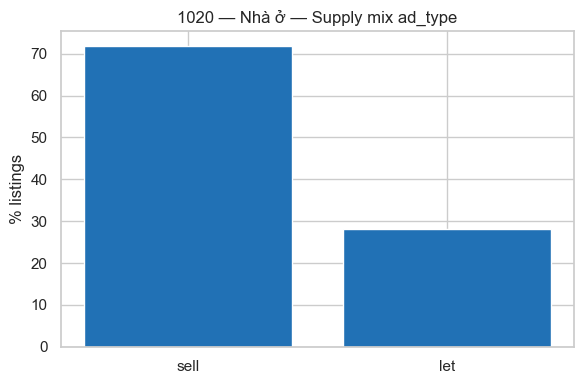

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_category_behavior/1020/fig_01_supply_ad_type.png


**1020 — Nhà ở — Snapshot theo ad_type**

,ad_type,listing_days,avg_views_24h,avg_contacts_24h,avg_age_days,pct_days_with_contact
0,let,1856939,8.84,3.249,34.8,18.97
1,sell,7491444,4.68,2.391,41.2,8.55


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**1020 — Nhà ở — Phân tầng event (login, không gom other=contact)**

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**1020 — Nhà ở — Cấu thành other_interaction (surface × device)**

,surface,device,events,users,sessions,pct_of_other_interaction
0,ad_view,Desktop,672437,53326,205471,36.39
1,ad_view,Android,460897,71294,218603,24.94
2,ad_view,iOS,382187,75417,216149,20.68
3,ad_view,MSite,250366,34860,104980,13.55
4,adview,Desktop,50568,16299,26459,2.74
5,adview,MSite,31061,13351,19470,1.68
6,adview,Android,494,441,467,0.03
7,adview,iOS,2,2,2,0.00


**1020 — Nhà ở — other_interaction theo surface**

,surface,events,pct_of_other_interaction
0,ad_view,1761691,95.57
1,adview,81735,4.43


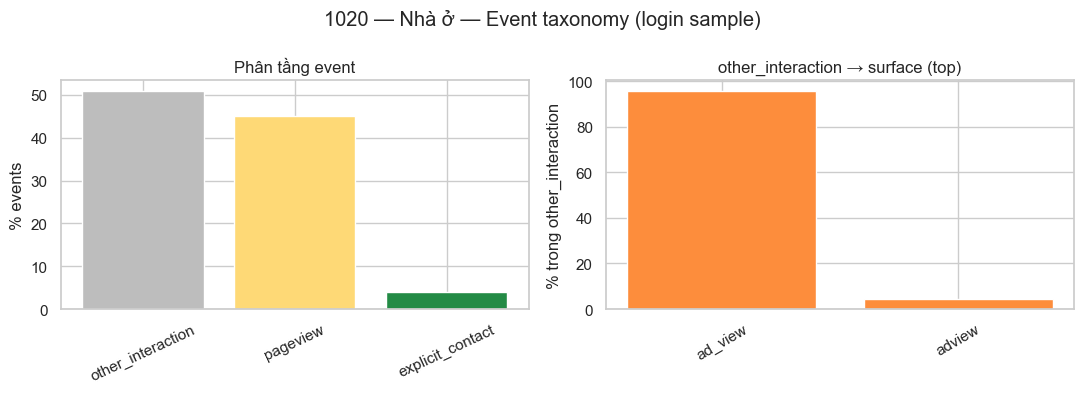

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_category_behavior/1020/fig_03_event_layers_and_other_surface.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**1020 — Nhà ở — Device (login, all events)**

,device,events,users,sessions,pct_events
0,iOS,1310709,152029,607843,36.15
1,Desktop,948765,60164,266227,26.16
2,Android,941214,106531,419997,25.96
3,MSite,425526,44325,156448,11.73


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**1020 — Nhà ở — Session funnel % (login; contact = explicit only)**

,stage,pct_of_sessions
0,search,4.06
1,view,70.66
2,consider,65.90
3,explicit_contact,8.38
4,other_interaction,53.65


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

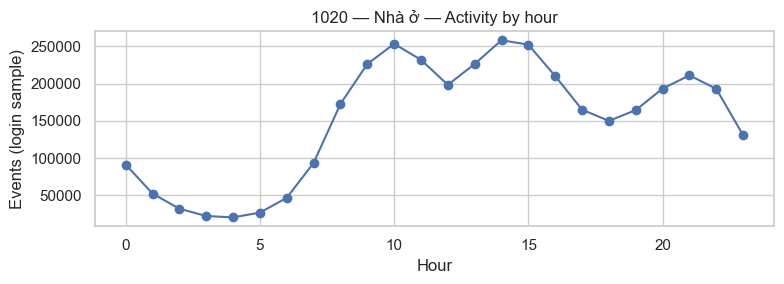

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_category_behavior/1020/fig_03_events_hour.png


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**1020 — Nhà ở — Interactions aggregate (login users)**

,adviews,leads,messages,avg_chat_turns,users,items
0,11051255,1467435,1639355,0.45,386055,257636


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**1020 — Nhà ở — Lead segments (login users)**

,segment,users,pct
2,D_other,313662,81.64
1,C_spam_broker,47581,12.38
0,A_high_intent,22961,5.98


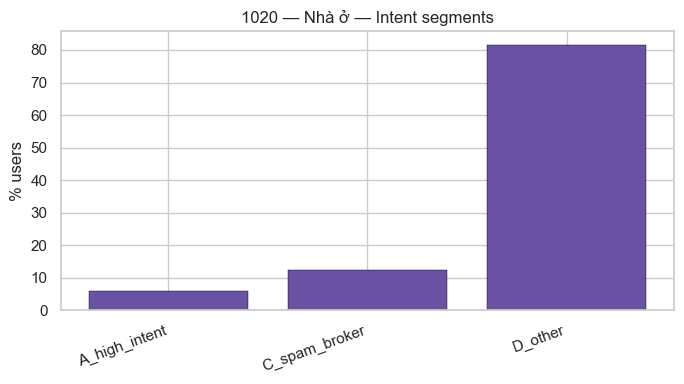

Saved /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_category_behavior/1020/fig_04_lead_segments.png


**1020 — Nhà ở — Marketing scorecard (draft)**

,layer,metric,value,signal,marketing_note
0,supply,let_share_pct,28.25,yếu,Tỷ trọng cho thuê trong catalog
1,supply,sell_share_pct,71.75,mạnh,Tỷ trọng bán trong catalog
2,behavior_login,explicit_contact_event_pct,4.06,cần cải thiện,Contact thật (view_phone/chat/zalo/sms) — gắn ...
3,behavior_login,other_interaction_event_pct,50.82,theo dõi riêng,Chủ yếu ad_view surface — KHÔNG gom vào contac...
4,behavior_login,other_interaction_top_surface_pct,95.57,cấu trúc,other_interaction top surface=ad_view
5,behavior_login,session_explicit_contact_pct,8.38,mạnh,% session login có ≥1 explicit contact
6,interactions_login,high_intent_user_pct,5.98,yếu,User login high-intent
7,interactions_login,window_shopper_pct,0.00,ổn,"User xem nhiều, không lead"


Done 1020 — Nhà ở


In [6]:
for cat in CATEGORIES:
    deepdive_category(cat)


---

### Đọc scorecard & đào sâu thêm (gợi ý)

- Mở `05_marketing_scorecard.csv` từng folder → chuyển thành slide **điểm mạnh / điểm yếu / hành động marketing**.  
- Drill thêm **một cột** nếu thấy signal: ví dụ chỉ `ad_type=let` → lặp `03_*` + funnel; chỉ top 3 `city_name` → supply + events.  
- `query` / search intent: tham khảo `eda_demand_deep_dive.ipynb` (NLP), lọc `category={cat}` + login.  
- **Event:** không gom `other_interaction` (~95% `surface=ad_view`) với explicit contact (~4% events). Funnel contact = explicit only.

Không so sánh 1010 vs 1020 trên cùng chart — so sánh **nội bộ** (let vs sell, city, segment).

**Liên quan:** `eda_category_1010_1020_performance.ipynb` (CVR catalog); `eda_category_1010_1020_clustering.ipynb` (cluster profiles).